# Modeler - Entrenamiento y evaluacion de modelos de churn

Notebook de modelado del TP3. Recibe las features ya transformadas (`features_train.parquet`, `features_test.parquet`) generadas por el notebook 3 (Training) y produce:

- **Baseline**: `DecisionTreeClassifier` con parametros por defecto
- **DT optimizado**: GridSearchCV sobre DecisionTree
- **Modelo potente**: `RandomForestClassifier` + GridSearchCV
- **Analisis SHAP** sobre Random Forest
- **Evaluacion final** en test set: matriz de confusion, precision, recall, F1, ROC-AUC

El test set solo se toca en la seccion de evaluacion final (seccion 7).

## 0. Setup

In [23]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

FEATURES_TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "features_train.parquet"
FEATURES_TEST_PATH  = PROJECT_ROOT / "data" / "processed" / "features_test.parquet"
TARGET_TRAIN_PATH   = PROJECT_ROOT / "data" / "processed" / "target_train.csv"
TARGET_TEST_PATH    = PROJECT_ROOT / "data" / "processed" / "target_test.csv"
MODELS_OUTPUT_DIR   = PROJECT_ROOT / "outputs" / "models"
MODELS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["roc_auc", "f1", "recall", "precision"]

## 1. Ingenieria de features

El pipeline (`src/features/pipeline.py`) ya aplico las transformaciones sobre el split de entrenamiento. Las 38 columnas del parquet son:

| Grupo | Cantidad | Detalle |
|---|---|---|
| Numericas base | 12 | Variables originales del dataset menos `DaySinceLastOrder` |
| Numericas derivadas | 4 | Features de negocio construidas a partir del EDA |
| Segmentacion binaria | 5 | Flags de ciclo de vida y frecuencia del cliente |
| Categoricas OHE | 17 | 5 variables categoricas expandidas con One-Hot Encoding |

**Features derivadas (decision de negocio):**

- `valor_cliente_proxy` = `OrderCount` * `CashbackAmount` — estima el valor economico del cliente segun volumen y cashback acumulado.
- `coupon_per_order` = `CouponUsed` / `OrderCount` — intensidad de uso de cupones por orden; separa clientes que usan cupones sistematicamente de los ocasionales.
- `cashback_per_order` = `CashbackAmount` / `OrderCount` — cashback promedio por orden; normaliza el beneficio por nivel de actividad.
- `complain_x_satisfaction` = `Complain` * `SatisfactionScore` — interaccion directa de H7: captura el efecto combinado de tener reclamo con nivel de satisfaccion.

**Flags de segmentacion binaria (Decision 29):**

- `is_new_customer` = Tenure <= 3 meses — ventana de mayor riesgo de churn temprano.
- `is_loyal_customer` = Tenure >= 18 meses — cliente establecido / senior.
- `is_low_freq_user` = OrderCount <= Q25 train — baja frecuencia de compra.
- `is_high_freq_user` = OrderCount >= Q75 train — alta frecuencia de compra.
- `is_high_value` = CashbackAmount >= mediana train — proxy de alto valor economico.

`DaySinceLastOrder` fue excluida del modelo (Decision 15): es retroactiva y no sirve como señal de alerta temprana en produccion.

In [24]:
from src.features.pipeline import (
    BASE_NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    DERIVED_NUMERIC_FEATURES,
    NUMERIC_FEATURES,
)

X_train = pd.read_parquet(FEATURES_TRAIN_PATH)
X_test  = pd.read_parquet(FEATURES_TEST_PATH)
y_train = pd.read_csv(TARGET_TRAIN_PATH)["Churn"].values
y_test  = pd.read_csv(TARGET_TEST_PATH)["Churn"].values

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train churn rate: {y_train.mean():.3%}")
print(f"y_test  churn rate: {y_test.mean():.3%}")
print()
print("Features numericas base:", BASE_NUMERIC_FEATURES)
print()
print("Features numericas derivadas:", DERIVED_NUMERIC_FEATURES)
print()
print("Features categoricas:", CATEGORICAL_FEATURES)
print()
print(f"Total columnas: {X_train.shape[1]}")


X_train: (4504, 38)
X_test:  (1126, 38)
y_train churn rate: 16.829%
y_test  churn rate: 16.874%

Features numericas base: ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'CashbackAmount']

Features numericas derivadas: ['valor_cliente_proxy', 'coupon_per_order', 'cashback_per_order', 'complain_x_satisfaction']

Features categoricas: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Total columnas: 38


## 1.1 Feature de clusterizacion K-Means (Decision 30)

Se agrega la pertenencia al cluster K-Means como feature numerica entera. El ajuste se hace **solo sobre `X_train`** para evitar leakage; la prediccion de cluster sobre `X_test` usa el modelo ya entrenado.

Se usan las 16 features continuas escaladas (`BASE_NUMERIC_FEATURES + DERIVED_NUMERIC_FEATURES`) porque RobustScaler les asigna distancias significativas. Las flags binarias (`is_*`) y columnas OHE quedan excluidas: las primeras tienen IQR nulo y distorsionarian la metrica euclidiana, las segundas ya aportan la misma informacion categorica de otro modo.

El numero de clusters se elige por coeficiente de silueta (k=2 a k=5); se prefiere el k con mayor silueta siempre que sea bajo e interpretable.

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features continuas ya escaladas por RobustScaler (excluye flags binarios y OHE)
KMEANS_COLS = BASE_NUMERIC_FEATURES + DERIVED_NUMERIC_FEATURES

sil_scores = {}
for k in range(2, 6):
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_train[KMEANS_COLS])
    sil_scores[k] = silhouette_score(X_train[KMEANS_COLS], labels_tmp)

print("Coeficiente de silueta por k (X_train, features continuas escaladas):")
for k, s in sil_scores.items():
    marker = " <-- elegido" if k == max(sil_scores, key=sil_scores.get) else ""
    print(f"  k={k}: {s:.4f}{marker}")

BEST_K = max(sil_scores, key=sil_scores.get)

Coeficiente de silueta por k (X_train, features continuas escaladas):
  k=2: 0.4154 <-- elegido
  k=3: 0.2684
  k=4: 0.1684
  k=5: 0.1668


In [26]:
km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
km_final.fit(X_train[KMEANS_COLS])

X_train = X_train.copy()
X_test  = X_test.copy()
X_train["kmeans_cluster"] = km_final.labels_
X_test["kmeans_cluster"]  = km_final.predict(X_test[KMEANS_COLS])

print(f"K-Means k={BEST_K} ajustado sobre X_train. Feature 'kmeans_cluster' agregada.")
print(f"Distribucion train: {pd.Series(X_train['kmeans_cluster']).value_counts().sort_index().to_dict()}")
print(f"Distribucion test:  {pd.Series(X_test['kmeans_cluster']).value_counts().sort_index().to_dict()}")
print(f"Total columnas: X_train={X_train.shape[1]}, X_test={X_test.shape[1]}")

K-Means k=2 ajustado sobre X_train. Feature 'kmeans_cluster' agregada.
Distribucion train: {0: 3803, 1: 701}
Distribucion test:  {0: 935, 1: 191}
Total columnas: X_train=39, X_test=39


## 2. Baseline: DecisionTreeClassifier

Arbol de decision con parametros por defecto y `class_weight='balanced'` para compensar el desbalance (~17% churn). Sirve como piso de comparacion para el modelo potente.

Se evalua con cross-validation estratificada de 5 folds. La metrica principal es ROC-AUC porque accuracy es misleading con clases desbalanceadas (un modelo que predice "nadie churna" alcanza 83% de accuracy).

In [27]:
dt_baseline = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)

cv_baseline = cross_validate(
    dt_baseline, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1
)

print("Decision Tree baseline (CV 5-fold):")
print("-" * 40)
for metric in SCORING:
    scores = cv_baseline[f"test_{metric}"]
    print(f"  {metric:12s}: {scores.mean():.4f} (+/- {scores.std():.4f})")


Decision Tree baseline (CV 5-fold):
----------------------------------------
  roc_auc     : 0.8702 (+/- 0.0285)
  f1          : 0.7775 (+/- 0.0440)
  recall      : 0.7890 (+/- 0.0529)
  precision   : 0.7679 (+/- 0.0467)


## 3. Decision Tree optimizado: GridSearchCV

Busqueda de hiperparametros sobre el espacio definido por la catedra. `scoring='roc_auc'` como criterio de seleccion para mantener consistencia con la metrica principal.

In [28]:
dt_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20],
    "class_weight": [None, "balanced"],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_params,
    cv=CV,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

print(f"Mejor ROC-AUC (CV): {grid_dt.best_score_:.4f}")
print(f"Mejores parametros: {grid_dt.best_params_}")


Fitting 5 folds for each of 160 candidates, totalling 800 fits
Mejor ROC-AUC (CV): 0.9133
Mejores parametros: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 20}


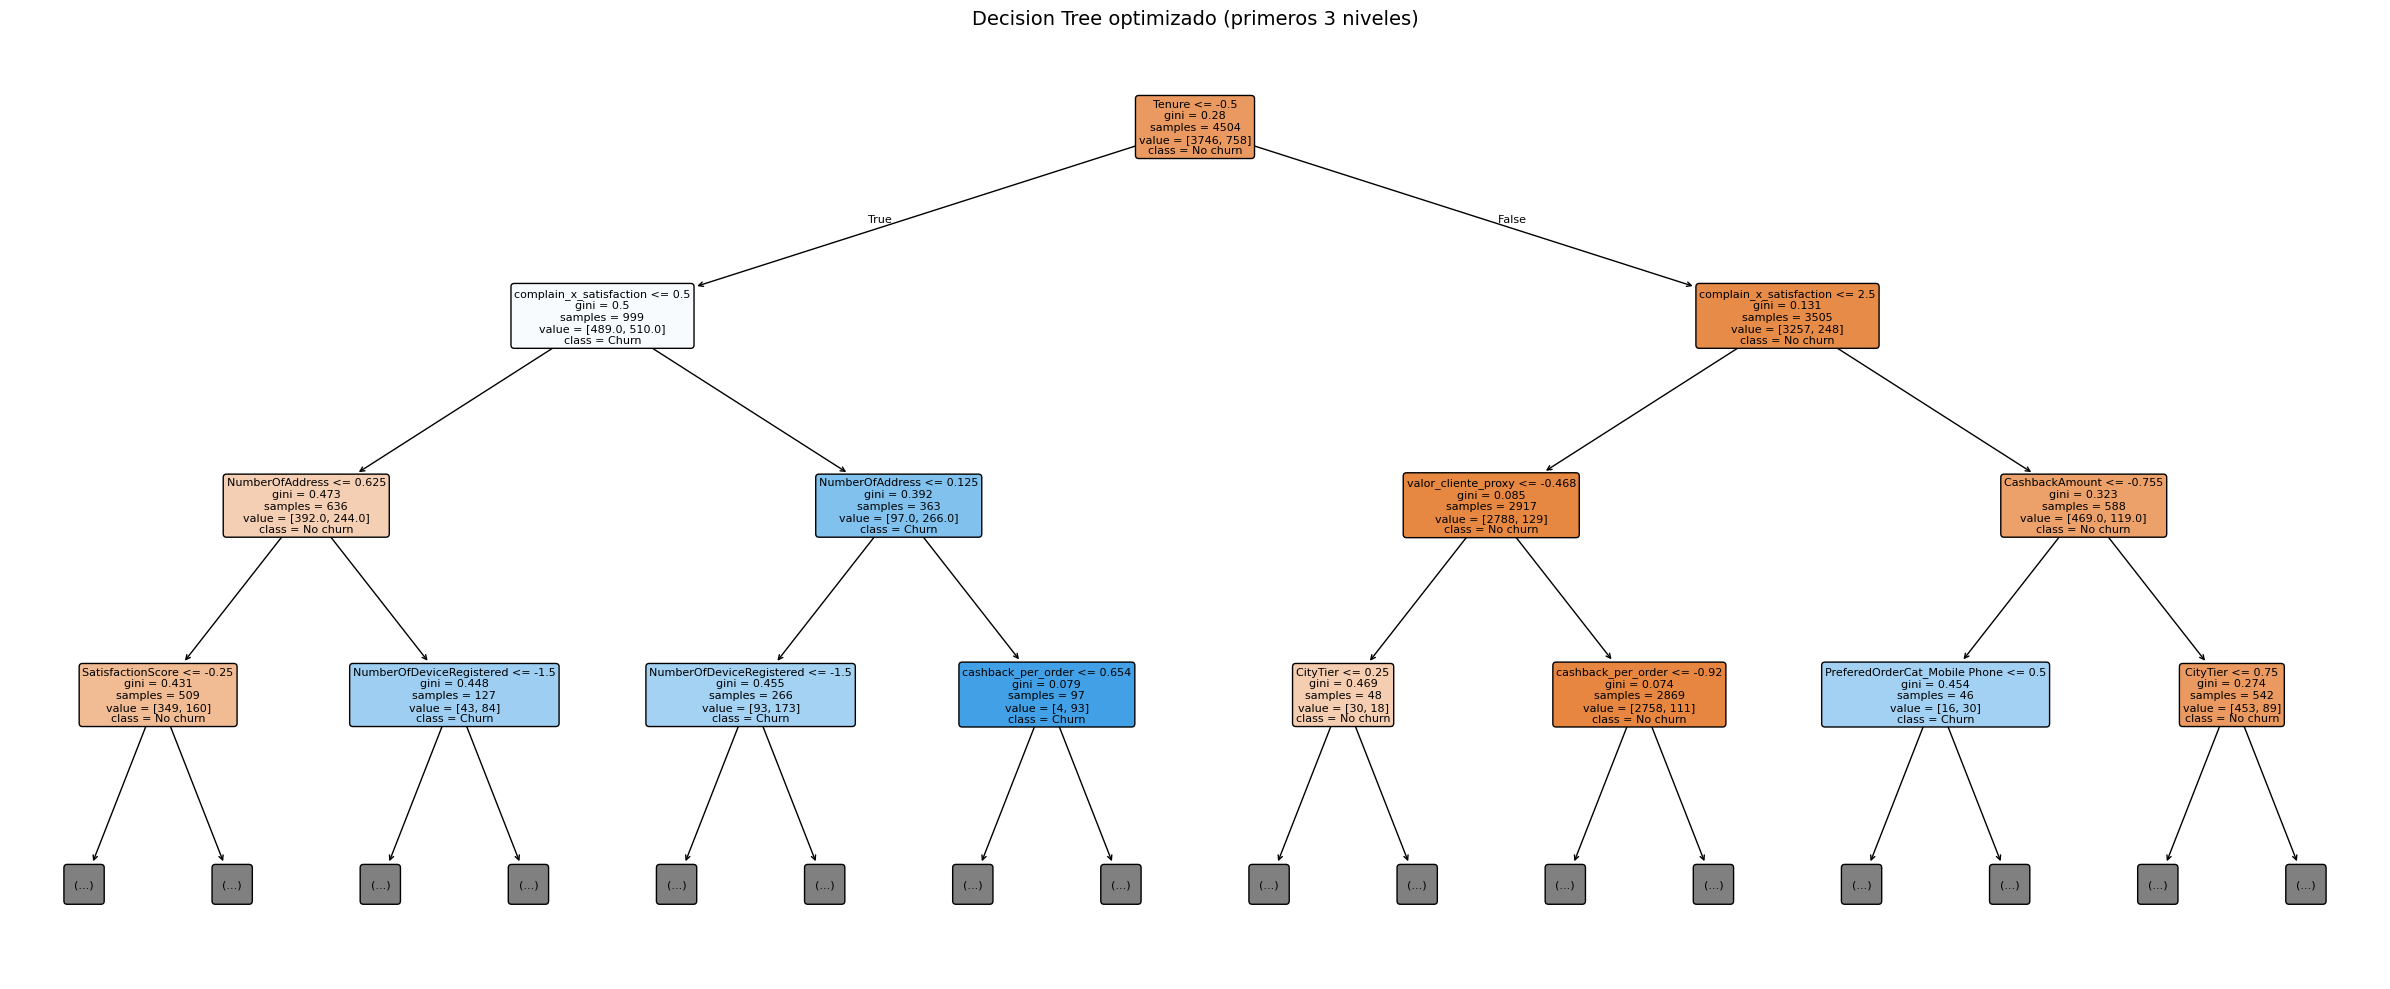

Guardado: dt_tree.png


In [29]:
# Visualizacion del arbol optimizado (primeros 3 niveles para legibilidad)
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    best_dt,
    feature_names=list(X_train.columns),
    class_names=["No churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    max_depth=3,
)
plt.title("Decision Tree optimizado (primeros 3 niveles)", fontsize=14)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "dt_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: dt_tree.png")


## 4. Random Forest con GridSearchCV

Modelo potente, ahora regularizado para reducir overfitting. La grilla evita arboles completamente libres (`max_depth=None`) y hojas de 1 observacion, que en la corrida anterior permitian memorizar el train.

Se mantiene `max_features='sqrt'` para diversificar los arboles y se agrega `max_samples` para que cada arbol vea una submuestra bootstrap del train.

In [30]:
rf_params = {
    "n_estimators": [200],
    "max_depth": [6, 8, 10, 12],
    "min_samples_leaf": [5, 10, 20],
    "min_samples_split": [10, 20, 40],
    "max_features": ["sqrt"],
    "class_weight": ["balanced", "balanced_subsample"],
    "max_samples": [0.70, 0.85],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        bootstrap=True,
    ),
    rf_params,
    cv=CV,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
best_rf_idx = grid_rf.best_index_
rf_train_auc = grid_rf.cv_results_["mean_train_score"][best_rf_idx]
rf_cv_auc = grid_rf.cv_results_["mean_test_score"][best_rf_idx]
rf_gap_auc = rf_train_auc - rf_cv_auc

print(f"Mejor ROC-AUC train (CV interno): {rf_train_auc:.4f}")
print(f"Mejor ROC-AUC validacion (CV): {rf_cv_auc:.4f}")
print(f"Gap train-CV ROC-AUC: {rf_gap_auc:.4f}")
print(f"Mejores parametros: {grid_rf.best_params_}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Mejor ROC-AUC train (CV interno): 0.9904
Mejor ROC-AUC validacion (CV): 0.9523
Gap train-CV ROC-AUC: 0.0381
Mejores parametros: {'class_weight': 'balanced', 'max_depth': 12, 'max_features': 'sqrt', 'max_samples': 0.85, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}


## 5. Comparacion de modelos

Se comparan los tres modelos usando las mismas metricas CV para un juicio justo. El test set todavia no se toca.

Ademas se reporta el gap train-CV del Random Forest regularizado para controlar que el modelo no este memorizando el train.

In [31]:
cv_best_dt = cross_validate(best_dt, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
cv_best_rf = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=CV,
    scoring=SCORING,
    n_jobs=-1,
    return_train_score=True,
)

comparison = {}
for label, cv_res in [
    ("DT baseline", cv_baseline),
    ("DT optimizado", cv_best_dt),
    ("RF regularizado", cv_best_rf),
]:
    comparison[label] = {
        metric: round(cv_res[f"test_{metric}"].mean(), 4) for metric in SCORING
    }

comparison_df = pd.DataFrame(comparison).T
comparison_df.index.name = "modelo"
print("Comparacion CV 5-fold (medias):")
print(comparison_df.to_string())

rf_overfit_check = pd.DataFrame({
    "train_mean": {
        metric: cv_best_rf[f"train_{metric}"].mean() for metric in SCORING
    },
    "cv_mean": {
        metric: cv_best_rf[f"test_{metric}"].mean() for metric in SCORING
    },
})
rf_overfit_check["gap_train_cv"] = (
    rf_overfit_check["train_mean"] - rf_overfit_check["cv_mean"]
)

print("\nChequeo overfitting RF regularizado (train vs CV):")
print(rf_overfit_check.round(4).to_string())

Comparacion CV 5-fold (medias):
                 roc_auc      f1  recall  precision
modelo                                             
DT baseline       0.8702  0.7775  0.7890     0.7679
DT optimizado     0.9133  0.7080  0.6873     0.7310
RF regularizado   0.9523  0.7418  0.8048     0.6894

Chequeo overfitting RF regularizado (train vs CV):
           train_mean  cv_mean  gap_train_cv
roc_auc        0.9904   0.9523        0.0381
f1             0.8710   0.7418        0.1292
recall         0.9551   0.8048        0.1504
precision      0.8005   0.6894        0.1112


## 6. Analisis SHAP (Random Forest regularizado final)

SHAP explica el fenomeno de churn, no solo el modelo. Visualizaciones:

- **Summary plot**: distribucion global de impacto por feature
- **Bar plot**: importancia media absoluta (para audiencia no tecnica)
- **Waterfall plot**: desglose de un caso concreto de churn detectado

In [32]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# shap_values es lista [class0_array, class1_array] para clasificacion binaria
sv_churn = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]
ev_churn = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

print(f"SHAP values shape (clase churn): {sv_churn.shape}")
print(f"Expected value (clase churn): {ev_churn:.4f}")


SHAP values shape (clase churn): (1126, 39)
Expected value (clase churn): 0.4999


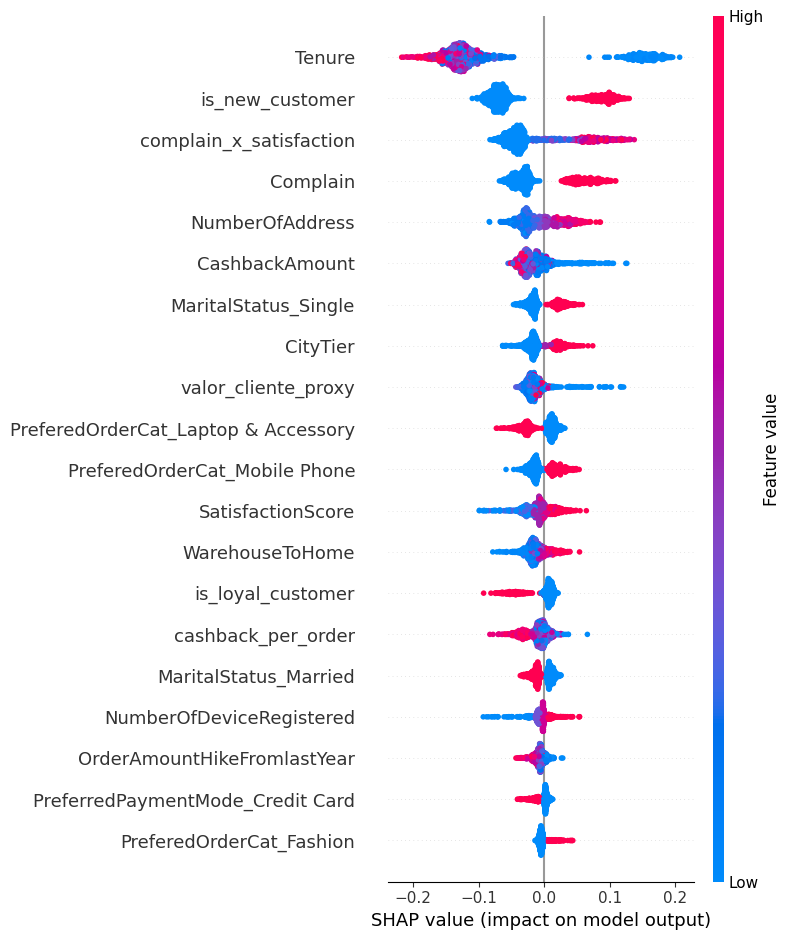

Guardado: shap_summary.png


In [33]:
# Summary plot: dot cloud (distribucion de impacto por feature)
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(sv_churn, X_test, show=False)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: shap_summary.png")


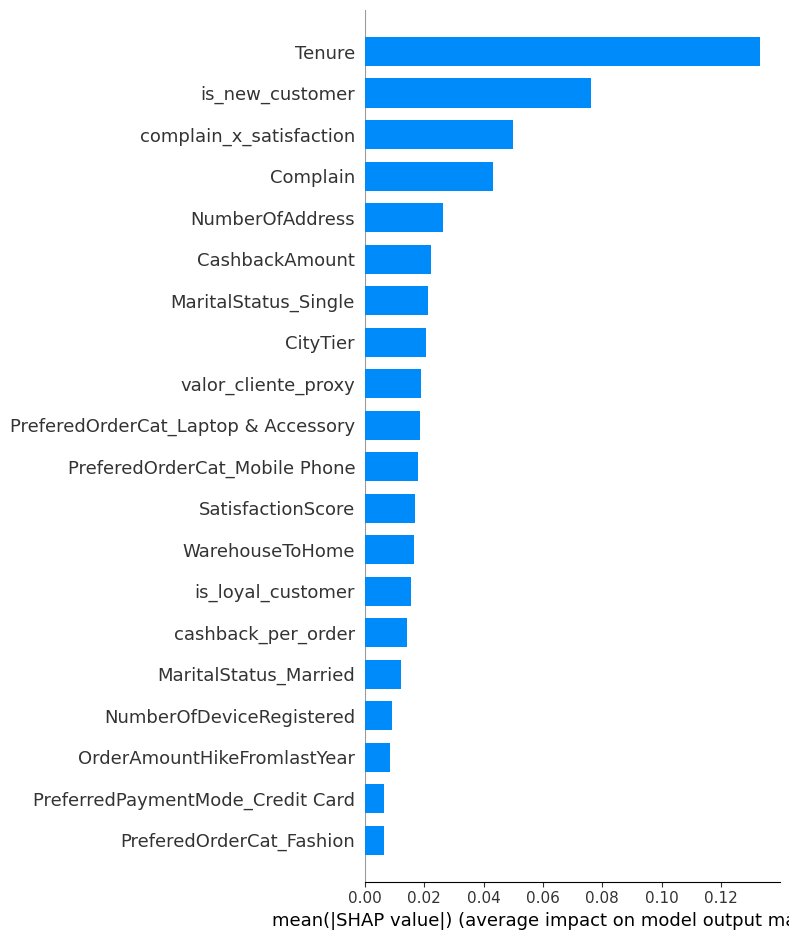

Guardado: shap_bar.png


In [34]:
# Bar plot: importancia media absoluta
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(sv_churn, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: shap_bar.png")


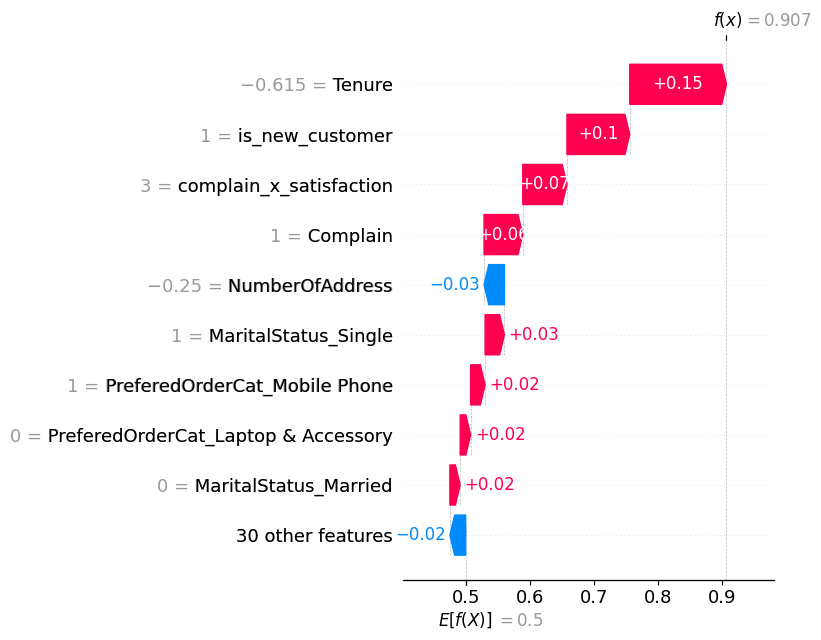

Waterfall para test idx=2 (verdadero positivo). Guardado.


In [35]:
# Waterfall plot: caso concreto de verdadero positivo
y_pred_rf = best_rf.predict(X_test)
tp_mask = (y_pred_rf == 1) & (y_test == 1)
example_idx = int(np.where(tp_mask)[0][0])

explanation_sample = shap.Explanation(
    values=sv_churn[example_idx],
    base_values=ev_churn,
    data=X_test.values[example_idx],
    feature_names=list(X_test.columns),
)
fig = plt.figure(figsize=(12, 7))
shap.plots.waterfall(explanation_sample, show=False)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "shap_waterfall_example.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Waterfall para test idx={example_idx} (verdadero positivo). Guardado.")


## 7. Evaluacion final en test set

El test set se usa una sola vez aqui. Se evalua el Random Forest regularizado con el umbral F2 optimo, porque el objetivo de negocio prioriza recall sobre precision. Se reportan todas las metricas requeridas: precision, recall, F1 y ROC-AUC.


In [36]:
from sklearn.metrics import fbeta_score, precision_score, recall_score

y_proba_final = best_rf.predict_proba(X_test)[:, 1]

BETA = 2.0
threshold_candidates = np.unique(np.r_[np.linspace(0, 1, 1001), y_proba_final])
threshold_rows = []
for threshold in threshold_candidates:
    y_pred_threshold = (y_proba_final >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "fbeta": fbeta_score(y_test, y_pred_threshold, beta=BETA, zero_division=0),
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values(
    ["fbeta", "recall", "precision", "threshold"], ascending=False
).iloc[0]

THRESHOLD_F2 = float(best_threshold_row["threshold"])
y_pred_final = (y_proba_final >= THRESHOLD_F2).astype(int)

print(f"Beta usado para evaluacion final: {BETA:g}")
print(f"Umbral F{BETA:g} optimo: {THRESHOLD_F2:.3f}")
print(f"F{BETA:g}: {best_threshold_row['fbeta']:.4f} | precision={best_threshold_row['precision']:.4f} | recall={best_threshold_row['recall']:.4f}")

# Matriz de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    ax=ax,
    display_labels=["No churn", "Churn"],
    colorbar=False,
    cmap="Blues",
)
plt.title(f"Random Forest - Matriz de confusion (test set, umbral F{BETA:g})")
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


Beta usado para evaluacion final: 2
Umbral F2 optimo: 0.380
F2: 0.8445 | precision=0.6146 | recall=0.9316


In [37]:
# Metricas por clase con umbral F2
print("Reporte de clasificacion (test set, umbral F2):")
print(classification_report(y_test, y_pred_final, target_names=["No churn", "Churn"]))

roc_auc = roc_auc_score(y_test, y_proba_final)
print(f"ROC-AUC (test): {roc_auc:.4f}")


Reporte de clasificacion (test set, umbral F2):
              precision    recall  f1-score   support

    No churn       0.98      0.88      0.93       936
       Churn       0.61      0.93      0.74       190

    accuracy                           0.89      1126
   macro avg       0.80      0.91      0.84      1126
weighted avg       0.92      0.89      0.90      1126

ROC-AUC (test): 0.9695


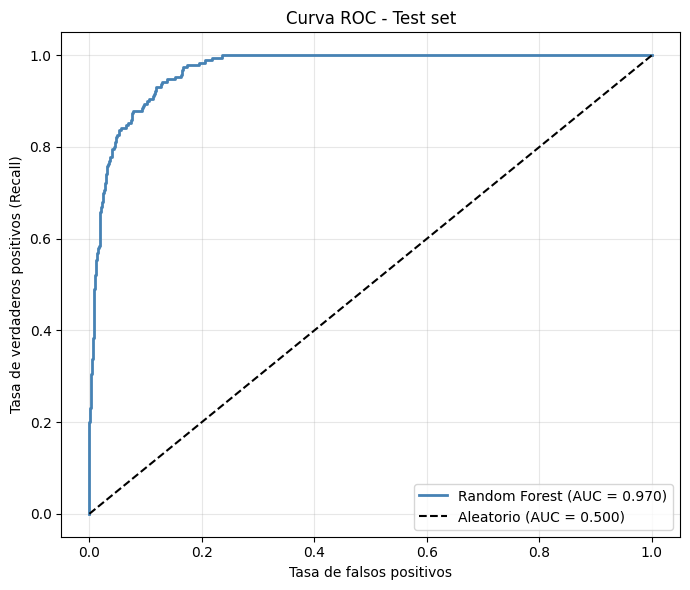

Guardado: roc_curve.png


In [38]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_final)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Random Forest (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Aleatorio (AUC = 0.500)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos (Recall)")
ax.set_title("Curva ROC - Test set")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_OUTPUT_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: roc_curve.png")


In [39]:
# Comparacion DT optimizado vs RF regularizado en test set
y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

from sklearn.metrics import f1_score, precision_score, recall_score

test_results = pd.DataFrame({
    "DT optimizado": {
        "roc_auc": roc_auc_score(y_test, y_proba_dt),
        "f1":       f1_score(y_test, y_pred_dt),
        "recall":   recall_score(y_test, y_pred_dt),
        "precision":precision_score(y_test, y_pred_dt),
    },
    "RF regularizado (umbral F2)": {
        "roc_auc": roc_auc,
        "f1":       f1_score(y_test, y_pred_final),
        "recall":   recall_score(y_test, y_pred_final),
        "precision":precision_score(y_test, y_pred_final),
    },
}).T.round(4)

print("Resultados en test set:")
print(test_results.to_string())

Resultados en test set:
                             roc_auc      f1  recall  precision
DT optimizado                 0.9416  0.7230  0.7211     0.7249
RF regularizado (umbral F2)   0.9695  0.7406  0.9316     0.6146


## 8. Estrategia de intervencion segmentada (Decision 33)

En lugar de elegir un umbral unico, se usan dos umbrales para asignar acciones proporcionales al nivel de riesgo:

- **Alta prioridad (proba >= 0.50):** clientes con alta confianza de churn. Justifican una accion costosa y personalizada (llamada, descuento significativo, oferta de retension).
- **Media prioridad (umbral F2 optimo <= proba < 0.50):** clientes con riesgo relevante que conviene alcanzar para priorizar recall. Se los trata con una accion barata y automatizable (mail, cupon, notificacion push).
- **Sin accion (proba < umbral F2 optimo):** riesgo bajo, no se interviene.

Con beta=2 se prioriza recall sobre precision. Por eso el umbral F2 se usa como piso de intervencion, y el umbral 0.50 separa los casos de mayor certeza para accion costosa.

In [43]:
THRESHOLD_HIGH = 0.50
THRESHOLD_LOW  = THRESHOLD_F2

tier = np.select(
    [y_proba_final >= THRESHOLD_HIGH,
     y_proba_final >= THRESHOLD_LOW],
    ["1_alta_prioridad", "2_media_prioridad"],
    default="3_sin_accion",
)

print(f"Beta usado para threshold tuning: {BETA:g}")
print(f"F{BETA:g} optimo: {best_threshold_row['fbeta']:.4f} | precision={best_threshold_row['precision']:.4f} | recall={best_threshold_row['recall']:.4f}")
print(f"Umbrales: alta_prioridad >= {THRESHOLD_HIGH:.2f} | media_prioridad >= {THRESHOLD_LOW:.3f}")
print()
print(f"{'Segmento':<22} {'Clientes':>9} {'Churners reales':>16} {'Falsos pos.':>12}   Accion sugerida")
print("-" * 95)
for t, accion in [
    ("1_alta_prioridad",  "Costosa: llamada / descuento significativo"),
    ("2_media_prioridad", "Barata:  mail / cupon / notificacion"),
    ("3_sin_accion",      "Ninguna"),
]:
    mask    = tier == t
    n_total = int(mask.sum())
    n_churn = int(((tier == t) & (y_test == 1)).sum())
    n_fp    = int(((tier == t) & (y_test == 0)).sum())
    pct     = n_churn / y_test.sum() * 100
    print(f"  {t:<20} {n_total:>9}  {n_churn:>9} ({pct:4.1f}%)  {n_fp:>10}   {accion}")

n_missed  = int(((tier == "3_sin_accion") & (y_test == 1)).sum())
n_covered = int(y_test.sum()) - n_missed
print()
print(f"Churners cubiertos: {n_covered}/{int(y_test.sum())} ({n_covered/y_test.sum()*100:.1f}%)")
print(f"Churners perdidos:  {n_missed}/{int(y_test.sum())}")

Beta usado para threshold tuning: 2
F2 optimo: 0.8445 | precision=0.6146 | recall=0.9316
Umbrales: alta_prioridad >= 0.50 | media_prioridad >= 0.380

Segmento                Clientes  Churners reales  Falsos pos.   Accion sugerida
-----------------------------------------------------------------------------------------------
  1_alta_prioridad           225        161 (84.7%)          64   Costosa: llamada / descuento significativo
  2_media_prioridad           63         16 ( 8.4%)          47   Barata:  mail / cupon / notificacion
  3_sin_accion               838         13 ( 6.8%)         825   Ninguna

Churners cubiertos: 177/190 (93.2%)
Churners perdidos:  13/190


## 9. Guardar modelo final

In [44]:
import pickle

MODEL_PATH = MODELS_OUTPUT_DIR / "best_rf.pkl"
with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_rf, f)
print(f"Modelo guardado en: {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Parametros: {best_rf.get_params()}")

Modelo guardado en: outputs\models\best_rf.pkl
Parametros: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': 0.85, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
